# Optimization Methods: DNN Forward / Backward Propagation

이 노트북은 첨부 실습의 Packages → Gradient Descent → Mini-Batch → model() → 학습 결과 흐름을 활용했습니다.
평가 조건에 맞춰 NumPy로 Dense, ReLU, Tanh, Softmax Cross Entropy의 순전파와 역전파를 직접 구현합니다.

**실행 방법:** Google Colab에 `Optimization.ipynb`를 업로드한 뒤 **런타임 → 모두 실행**을 선택합니다.
필요한 라이브러리는 NumPy와 Matplotlib입니다. 입력과 중간 출력은 `(batch, features)`로 유지합니다.
학습 로그, gradient checking 결과, 학습 곡선과 결정 경계는 이 노트북의 출력에서 확인합니다.


## Packages

원본 실습처럼 NumPy와 Matplotlib을 사용하고, `src/opt_utils.py`에서 구현 함수를 import합니다.
순전파·역전파, 데이터 생성, 학습 함수의 실제 구현은 이 소스 파일에 있습니다.
ZIP을 푼 폴더에서는 동봉된 파일을 사용합니다. Colab에 노트북만 업로드했으면
첫 셀이 GitHub에서 같은 버전의 소스 파일을 자동으로 다운로드한 뒤 import합니다.
아래 출력에서 실제로 불러온 파일을 확인할 수 있습니다.


In [1]:
from pathlib import Path
from urllib.request import urlopen
import sys

import numpy as np
import matplotlib.pyplot as plt

# ZIP을 푼 폴더에서는 동봉된 소스를 사용합니다.
# Colab에 노트북만 업로드한 경우 같은 버전의 소스를 내려받습니다.
source_dir = Path("src")
source_path = source_dir / "opt_utils.py"
if not source_path.is_file():
    source_url = (
        "https://raw.githubusercontent.com/piaa1004/python/"
        "0312c7b4f4570e5416d84f97bbb2ffad4c6cc1d6/src/opt_utils.py"
    )
    with urlopen(source_url, timeout=30) as response:
        source_code = response.read()
    source_dir.mkdir(exist_ok=True)
    source_path.write_bytes(source_code)
    print("Downloaded: src/opt_utils.py")

sys.path.insert(0, str(source_dir.resolve()))
import opt_utils

print("Imported module:", Path(opt_utils.__file__).relative_to(Path.cwd()).as_posix())


Imported module: src/opt_utils.py


## 1. Gradient Descent

원본 실습의 딕셔너리 키 `W1`, `b1`, `dW1`, `db1`과 업데이트 함수를 유지합니다.
미니배치마다 다음 식으로 SGD 업데이트를 수행합니다.

$$W_l \leftarrow W_l-\eta\,dW_l,\qquad b_l\leftarrow b_l-\eta\,db_l.$$

업데이트 전에 파라미터와 gradient의 shape가 같은지 확인합니다.


In [2]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    update_parameters_with_gd,
)


## 2. Mini-Batch Gradient Descent

`get_batches(X, y, batch_size, shuffle=True)`는 배치 iterator입니다.
같은 인덱스로 입력과 label을 섞고 마지막 작은 배치도 반환합니다.
원본 실습의 `random_mini_batches`는 이 iterator를 사용하는 래퍼로 남겨 둡니다.
실제 학습에서는 epoch마다 새로운 순열을 만드는 `get_batches`를 사용합니다.


In [3]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    get_batches,
    random_mini_batches,
)


## 3. Data pipeline

NumPy로 반지름이 다른 두 동심원 클래스를 생성합니다.
이 데이터는 직선 하나로 구분하기 어려우므로 은닉층과 비선형 활성함수의 역할을 확인하기 좋습니다.

먼저 전체 데이터를 **train/test = 8:2**로 나눈 뒤,
train의 20%를 validation으로 분리합니다. 최종 비율은 **64:16:20**이며
1,200개 기준 train 768개, validation 192개, test 240개입니다.
각 클래스 비율을 유지하도록 분할하고 train의 평균/표준편차로 세 분할을 표준화합니다.
validation으로 학습률을 선택하고 test는 선택 후 최종 평가에 사용합니다.


In [4]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    load_data,
    split_data,
    standardize,
    load_dataset,
)


## 4. Dense, Activation, Loss

**Dense의 계산 그래프**

배치 크기 $B$, 입력 차원 $D_{in}$, 출력 차원 $D_{out}$일 때
$X\in\mathbb{R}^{B\times D_{in}}$, $W\in\mathbb{R}^{D_{in}\times D_{out}}$,
$b\in\mathbb{R}^{1\times D_{out}}$입니다.

$$Z=XW+b,\qquad dW=X^T dZ,\qquad db=\sum_{i=1}^{B} dZ_i,\qquad dX=dZ W^T.$$

각 Dense는 입력 `X`와 출력 shape를 캐싱합니다.
`loss.backward()`에서 배치 평균 $1/B$를 적용하므로 Dense에서 다시 나누지 않습니다.

**활성함수 선택 이유**

첫 은닉층은 ReLU를 사용하여 비선형성을 추가하고 양수 구간에서 gradient를 전달합니다.
두 번째 은닉층은 Tanh를 사용합니다. Tanh의 출력 범위가 $[-1,1]$이며
미분 $1-\tanh^2(z)$을 직접 확인할 수 있습니다.
ReLU는 입력, Tanh는 출력 값을 캐싱하여 역전파에서 재사용합니다.

$$\mathrm{ReLU}'(z)=\mathbf{1}[z>0],\qquad \tanh'(z)=1-\tanh^2(z).$$

**손실함수 선택 이유**

두 클래스에 대한 출력 logits를 두 개 만드는 구조이므로 Softmax Cross Entropy를 선택합니다.
출력 Dense 뒤의 softmax는 손실함수 내부에서 계산합니다.
log-sum-exp 식으로 안정적으로 계산하고, 정수 label을 one-hot 방식으로 미분합니다.

$$L=-\frac{1}{B}\sum_{i=1}^{B}\log p_{i,y_i},\qquad
\frac{\partial L}{\partial z_{i,k}}=\frac{p_{i,k}-\mathbf{1}[k=y_i]}{B}.$$

He 초기화는 ReLU 앞의 가중치에, Xavier 초기화는 Tanh 앞과 출력 가중치에 적용합니다.
bias는 0으로 초기화합니다.


In [5]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    DenseLayer,
    ReLU,
    Tanh,
    SoftmaxCrossEntropy,
)


## 5. Deep Neural Network 컨테이너

| 순서 | 모듈 | 입력 → 출력 | 초기화 |
|---|---|---|---|
| 1 | Dense + ReLU | 2 → 16 | He, bias 0 |
| 2 | Dense + Tanh | 16 → 8 | Xavier, bias 0 |
| 3 | Dense 출력층 | 8 → 2 logits | Xavier, bias 0 |
| 4 | Softmax Cross Entropy | logits + label → loss | 파라미터 없음 |

Dense는 3개이며 은닉층은 2개입니다. 학습 파라미터 수는
`(2×16+16) + (16×8+8) + (8×2+2) = 202`개입니다.
`forward`는 레이어 리스트를 순서대로, `backward`는 역순으로 실행합니다.
`step(learning_rate)`는 원본의 `update_parameters_with_gd`를 호출하여 SGD를 수행합니다.


In [6]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    DeepNeuralNetwork,
    initialize_parameters,
    forward_propagation,
    backward_propagation,
    compute_cost,
    predict,
    evaluate,
)


## 6. Gradient checking

중앙차분으로 각 파라미터의 수치 gradient를 구하고 직접 구현한 gradient와 비교합니다.

$$g_{numeric}(\theta_j)=\frac{L(\theta_j+\epsilon)-L(\theta_j-\epsilon)}{2\epsilon},\qquad
\text{relative error}=\frac{\|g_{analytic}-g_{numeric}\|_2}
{\|g_{analytic}\|_2+\|g_{numeric}\|_2+10^{-12}}.$$

`epsilon=1e-5`, 통과 기준은 상대오차 `<1e-6`입니다.
최소 조건인 한 파라미터 검사를 확장하여 **모든 Dense의 W/b와 입력 X의 dX**를 검사합니다.
수치미분 중 변경한 값은 매번 복원하고 마지막에 캐시/gradient도 복원합니다.
ReLU는 0에서 미분 불가능하므로 검사 배치에서 0과의 거리도 확인합니다.


In [7]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    gradient_check,
)


## 7. model(): 학습 루프

원본 실습처럼 `epoch → mini-batch → forward → cost → backward → update` 순서입니다.
epoch가 끝나면 같은 파라미터로 전체 train/validation loss와 accuracy를 기록합니다.
마지막 작은 배치가 있더라도 `batch_loss` 계산에 샘플 수를 반영합니다.
학습률, 배치 크기, epoch 수는 `model`의 인자로 설정할 수 있습니다.


In [8]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    model,
)


## 8. 실험 및 시각화 함수

학습률 0.01과 0.1을 비교합니다. 두 실험은 데이터, 초기 가중치, 배치 순서,
모델 구조, 300 epoch, batch size 32를 동일하게 사용합니다.
마지막 validation loss로 실험을 선택한 뒤 test 성능을 평가합니다.
epoch별 지표는 `histories`에 기록하고 학습 곡선으로 확인합니다.


In [9]:
# 실제 구현: src/opt_utils.py
from opt_utils import (
    run_experiments,
    plot_learning_curves,
    plot_decision_boundary,
)


## 9. 실행: 데이터 확인

여기부터 실제 실행 결과를 계산합니다. seed를 고정했으므로 동일한 환경에서 재현할 수 있습니다.
정규화 통계는 train만으로 계산했는지 확인합니다.


     train: X(768, 2), y(768,), class counts=[384 384]
validation: X(192, 2), y(192,), class counts=[96 96]
      test: X(240, 2), y(240,), class counts=[120 120]
train mean after standardization: [ 3.98986399e-17 -4.06214414e-17]
train std after standardization: [1. 1.]


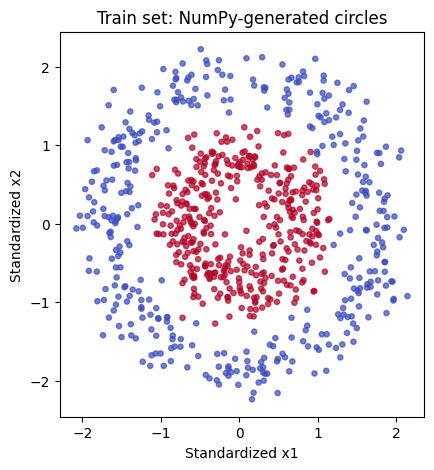

In [10]:
data = load_dataset()
X_train, y_train, X_val, y_val, X_test, y_test, stats = data

for name, X, y in (
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
):
    assert X.ndim == 2 and X.shape[1] == 2 and y.shape == (len(X),)
    print("%10s: X%s, y%s, class counts=%s" % (
        name, X.shape, y.shape, np.bincount(y, minlength=2)))

print("train mean after standardization:", X_train.mean(axis=0))
print("train std after standardization:", X_train.std(axis=0))
assert np.allclose(X_train.mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(X_train.std(axis=0), 1.0, atol=1e-12)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=14, alpha=0.7)
ax.set_title("Train set: NumPy-generated circles")
ax.set_xlabel("Standardized x1")
ax.set_ylabel("Standardized x2")
ax.set_aspect("equal")
plt.show()


## 10. 실행: 미니배치, 캐시, gradient shape, SGD 확인

배치 크기 31로 마지막 작은 배치까지 포함되는지 확인합니다.
다음으로 5개 샘플의 계산 그래프에서 forward shape와 캐시,
Dense의 `dW`, `db`, 전체 `dX`를 출력합니다.
마지막에는 직접 계산한 SGD 식과 실제 업데이트가 일치하는지 검증합니다.
이 확인용 모델은 학습 실험에서 사용하는 모델과 별도로 생성합니다.


In [11]:
demo_batches = random_mini_batches(X_train, y_train, mini_batch_size=31, seed=10)
assert sum(len(X_batch) for X_batch, _ in demo_batches) == len(X_train)
assert all(X_batch.ndim == 2 and y_batch.shape == (len(X_batch),)
           for X_batch, y_batch in demo_batches)
print("Mini-batches: count=%d, first=%s, last=%s" % (
    len(demo_batches), demo_batches[0][0].shape, demo_batches[-1][0].shape))

demo_network = initialize_parameters()
demo_X, demo_y = X_train[:5].copy(), y_train[:5].copy()
demo_out = demo_X
print("\nForward shapes and cache:")
for index, layer in enumerate(demo_network.layers, 1):
    demo_out = layer.forward(demo_out)
    assert layer.cache is not None
    print("%d. %-10s -> %s" % (index, type(layer).__name__, demo_out.shape))

demo_criterion = SoftmaxCrossEntropy()
demo_loss = demo_criterion.forward(demo_out, demo_y)
demo_dlogits = demo_criterion.backward()
demo_dX = demo_network.backward(demo_dlogits)
print("loss=%.6f, dlogits=%s, dX=%s" % (demo_loss, demo_dlogits.shape, demo_dX.shape))
assert demo_dX.shape == demo_X.shape

print("\nDense parameter / gradient shapes:")
for index, layer in enumerate(demo_network.dense_layers, 1):
    print("Dense %d: W=%s dW=%s | b=%s db=%s" % (
        index, layer.W.shape, layer.dW.shape, layer.b.shape, layer.db.shape))
    assert layer.W.shape == layer.dW.shape and layer.b.shape == layer.db.shape

demo_lr = 0.1
expected_parameters = [
    (layer.W - demo_lr * layer.dW, layer.b - demo_lr * layer.db)
    for layer in demo_network.dense_layers
]
demo_network.step(demo_lr)
for layer, (expected_W, expected_b) in zip(demo_network.dense_layers, expected_parameters):
    assert np.allclose(layer.W, expected_W) and np.allclose(layer.b, expected_b)
print("SGD verification: passed (parameter - learning_rate * gradient)")


Mini-batches: count=25, first=(31, 2), last=(24, 2)

Forward shapes and cache:
1. DenseLayer -> (5, 16)
2. ReLU       -> (5, 16)
3. DenseLayer -> (5, 8)
4. Tanh       -> (5, 8)
5. DenseLayer -> (5, 2)
loss=0.840969, dlogits=(5, 2), dX=(5, 2)

Dense parameter / gradient shapes:
Dense 1: W=(2, 16) dW=(2, 16) | b=(1, 16) db=(1, 16)
Dense 2: W=(16, 8) dW=(16, 8) | b=(1, 8) db=(1, 8)
Dense 3: W=(8, 2) dW=(8, 2) | b=(1, 2) db=(1, 2)
SGD verification: passed (parameter - learning_rate * gradient)


## 11. 실행: Gradient checking 결과

아래 출력의 상대오차와 최대 절대오차가 실제 수치미분 결과입니다.
마지막 `assert`를 통과해야 이어서 학습 실험을 진행합니다.


In [12]:
gradient_result = gradient_check(
    initialize_parameters(), X_train[:5].copy(), y_train[:5]
)
print("epsilon=%.1e, threshold=%.1e, minimum |ReLU input|=%.6e" % (
    gradient_result["epsilon"], gradient_result["threshold"],
    gradient_result["relu_min_abs_input"]))
print("\n%-12s %-10s %9s %18s %18s" % (
    "parameter", "shape", "checked", "relative error", "max abs error"))
for row in gradient_result["results"]:
    print("%-12s %-10s %9d %18.10e %18.10e" % (
        row["parameter"], str(tuple(row["shape"])), row["n_checked"],
        row["relative_error"], row["max_absolute_error"]))
print("Gradient check passed:", gradient_result["passed"])
assert gradient_result["passed"], "수치미분과 역전파 gradient가 일치하지 않습니다."


epsilon=1.0e-05, threshold=1.0e-06, minimum |ReLU input|=1.016958e-03

parameter    shape        checked     relative error      max abs error
W1           (2, 16)           32   8.1684983460e-11   1.1946332812e-11
b1           (1, 16)           16   6.2558029647e-11   1.5879304816e-11
W2           (16, 8)          128   1.2906902598e-10   2.0166951442e-10
b2           (1, 8)             8   3.5047985716e-11   1.1183644288e-11
W3           (8, 2)            16   1.5799866181e-11   7.3980821469e-12
b3           (1, 2)             2   5.6680466768e-11   1.1485729035e-11
X (dX)       (5, 2)            10   1.1488491226e-10   1.2679059191e-11
Gradient check passed: True


## 12. 실행: 300 epoch 학습과 학습률 비교

로그에는 첫 epoch와 50 epoch마다 train/validation loss 및 accuracy를 출력합니다.
`histories`에는 생략 없이 모든 epoch를 기록합니다.
아래 요약은 실제 실행 값으로 작성되며 test 성능으로 학습률을 선택하지 않습니다.


In [13]:
networks, histories, summary = run_experiments(data)

print("\nFinal experiment results:")
print("%-10s %10s %12s %12s %12s %12s" % (
    "experiment", "initial L", "train loss", "train acc", "val loss", "val acc"))
for row in summary["experiments"]:
    print("%-10s %10.6f %12.6f %11.2f%% %12.6f %11.2f%%" % (
        row["experiment"], row["initial_train_loss"], row["train_loss"],
        100 * row["train_accuracy"], row["val_loss"], 100 * row["val_accuracy"]))

print("Selected by final validation loss:", summary["selected_experiment"])
print("Final test: loss=%.6f, accuracy=%.2f%%" % (
    summary["test_loss"], 100 * summary["test_accuracy"]))
assert all(len(history) == 300 for history in histories.values())



Mini-batch SGD, learning_rate = 0.01
Epoch   1 | train loss 0.6668 acc 53.26% | val loss 0.6686 acc 50.00%


Epoch  50 | train loss 0.1581 acc 98.44% | val loss 0.1776 acc 96.88%


Epoch 100 | train loss 0.0676 acc 98.70% | val loss 0.0812 acc 97.92%


Epoch 150 | train loss 0.0462 acc 99.22% | val loss 0.0597 acc 98.44%


Epoch 200 | train loss 0.0366 acc 99.48% | val loss 0.0529 acc 98.44%


...

Epoch 100 | train loss 0.0131 acc 99.74% | val loss 0.0456 acc 97.40%


Epoch 150 | train loss 0.0136 acc 99.74% | val loss 0.0354 acc 97.92%


Epoch 200 | train loss 0.0099 acc 99.61% | val loss 0.0439 acc 98.44%


Epoch 250 | train loss 0.0083 acc 99.87% | val loss 0.0439 acc 97.92%


Epoch 300 | train loss 0.0073 acc 99.87% | val loss 0.0478 acc 97.92%

Final experiment results:
experiment  initial L   train loss    train acc     val loss      val acc
lr_0.01      0.712891     0.027470       99.61%     0.047796       97.92%
lr_0.1       0.712891     0.007302       99.87%     0.047773       97.92%
Selected by final validation loss: lr_0.1
Final test: loss=0.095187, accuracy=97.50%


## 13. 실행: 학습 곡선과 결정 경계

실선은 train, 점선은 validation입니다. 학습률에 따른 손실 변화와 정확도를 비교합니다.
선택된 모델의 결정 경계를 test 샘플과 함께 확인합니다.


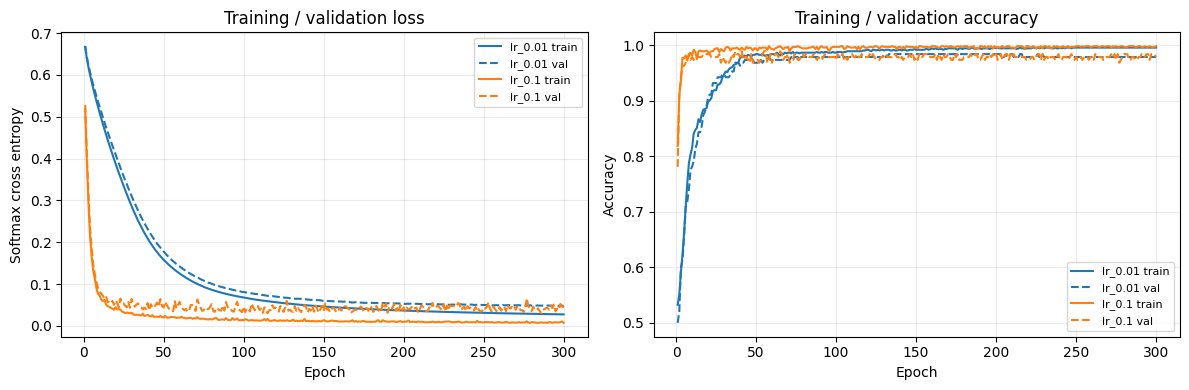

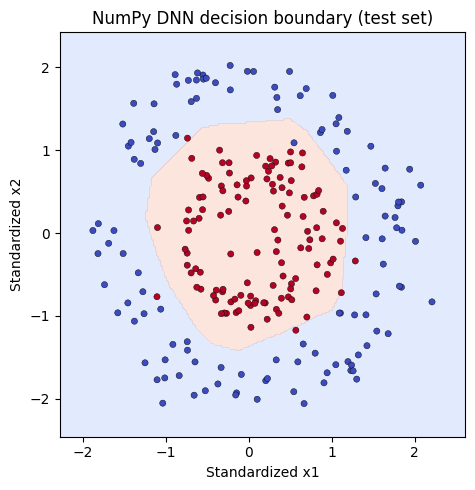

In [14]:
learning_figure = plot_learning_curves(histories)
plt.show()

selected_network = networks[summary["selected_experiment"]]
boundary_figure = plot_decision_boundary(selected_network, X_test, y_test)
plt.show()


## 14. 실험 결과 해석

- 학습률 0.1은 0.01보다 train loss가 빠르게 감소합니다.
- 최종 validation accuracy는 두 실험에서 같고 validation loss 차이도 작습니다.
- 모델 선택은 validation loss를 사용하며 test 성능은 선택 후 평가합니다.
- 직접 계산한 gradient와 수치미분의 상대오차가 `1e-6`보다 작은지 확인합니다.
- 구현 설명과 실제 실험 수치는 README에도 정리했습니다.
